# Convolutional Neural Network.
## Instructions and Requirements:
This week workshop will have two sections:

*   Section: 1
  *   In this section, we will implement and observe the operations of various layers used to build the CNN.
  *   By the end of the workshop, we expect you to be able to:
      1.   Explain the Convolution operation
      2.   Explain the pooling operation
      3.   Get familiar with various hyperparameters i.e. stride, padding

*   Section: 2
  *   In this section we will compile all the learning from section 1 to build a basic Convolutional Neural Network using Keras and Tensorflow.
  

##Convolution Summary:

We convolve (slide) a small matrix also known as Filter/kernel, performing element wise matrix multiplications to produce filter-map.

  *   Objective of a convolution operations:
        1.   Apply a set of weights-a filter- to extract local features.
        2.   Use Multiple filters to extract different features.
        3.   Spatially share parameters of each filter.

Mathematically it perform following:
$$ conv(I,K)_{xy} = ∑_{i=1}^{h}\sum_{j=1}^{w}K_{ij}.I_{x+i-1,y+j-1} \tag{1} $$

Where:
- $I$ input image matrix..
-$K$ kernel/Filter used to perform convolution.

Hyper-parameters in Convolution Operations:
*   Number of Filters(K)
*   Size of Filters(F)
*   Stride(S)
*   amount of zero padding(P)

Output Dimensions is given by:

\begin{align}
\mathbf{O}  = \frac{W_{in} -f + 2p}{s} + 1 \tag{2}
\end{align}

### Exercise-1.

Perform following Convolution Operations:

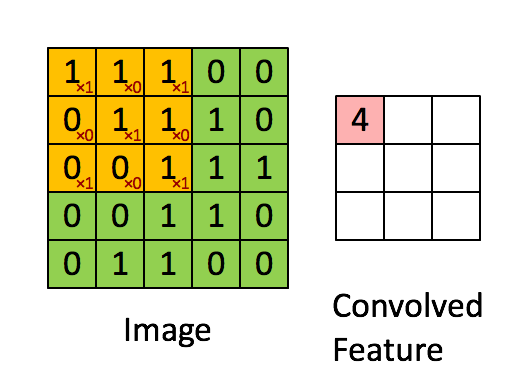

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [ ]:
# Defining the input matrix as above using np.array function.
I = np.array([[1, 1, 1, 0, 0], [0, 1, 1, 1 ,0], [0, 0, 1, 1, 1,], [0, 0, 1, 1, 0], [0, 1, 1, 0, 0]])

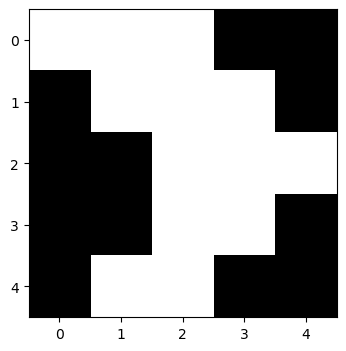

In [ ]:
# Visualizing the input.
plt.imshow(I)

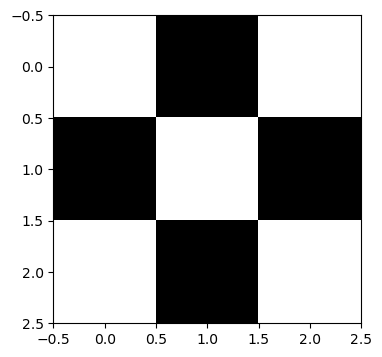

In [ ]:
# Defining the input matrix as above using np.matrix function.
K = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]])
# Visualizing the Filter.
plt.imshow(K)


Convolution Output:
[[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]


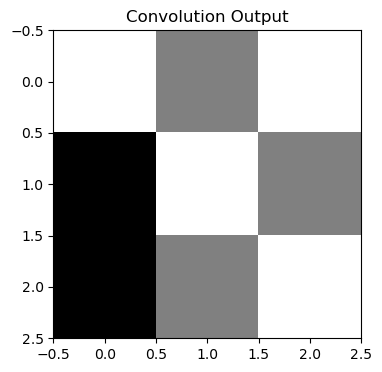

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def convolution(img, filter):
    """
    Function performs convolution operations.

    Arguments:
    img (ndarray): numpy array of an input image.
    filter (ndarray): numpy array of an input filter.

    Returns:
    filter_map (ndarray): Output matrix after convolution.
    """

    H, W = img.shape  # Height and width of image
    F, _ = filter.shape  # square filter

    # Compute output dimensions
    output_dimension = H - F + 1

    # Initialize output matrix
    filter_map = np.zeros((output_dimension, output_dimension))

    # Perform convolution operation
    for i in range(output_dimension):
        for j in range(output_dimension):
            # Extract the region of interest from image
            region = img[i:i+F, j:j+F]
            # Perform element-wise multiplication and sum
            filter_map[i, j] = np.sum(region * filter)

    return filter_map

# Define input matrix I
I = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

# Define filter K
K = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

# Compute convolution
output = convolution(I, K)
print("Convolution Output:")
print(output)

# Visualizing the output
plt.imshow(output)
plt.title("Convolution Output")
plt.show()


In [ ]:
img = convolution(I, K)

In [ ]:
assert img.shape == (3, 3), " Convolution Operation did not produce correct output"

Test Passed


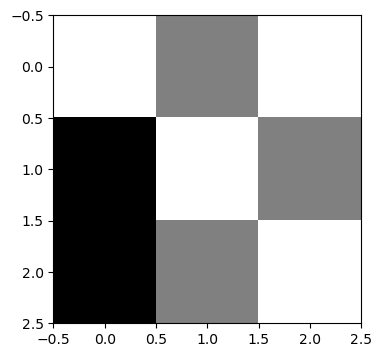

In [ ]:
plt.imshow(img)
print("Test Passed")

# Section-2: In this section we will build very basic CNN architecture, Compile and train our CNN model.

This will be further divided into following sections:


## Section-2.1: Data Pre-processing.

Expected structure of folder:

-/Datasets/

      --train/
        -- acai/....     
        -- cupuacu/---
        -- all the classes--

In [1]:
data_dir = "Downloads/FruitinAmazon/train"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [3]:
# Hyper-parameters:
batch_size = 32
img_height = 180
img_width = 180

### Load the Data:

We will use tf.keras.utility to load the image, for this function to work, your data should be in the structure suggested above.

We will do this for both training and validation dataset.

### Exercise:

1. To train a deep learning model we need to create a data pipeline, Multiple different approaches are available within keras framework;
one such framework is
  "tf.keras.utils.image_dataset_from_directory("parameter")

Implement above framework and explain the parameters you have used in the comment.

In [19]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [22]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory="/content/drive/MyDrive/FruitinAmazon/train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    directory="/content/drive/MyDrive/FruitinAmazon/train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation"
)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [23]:
print("Class Names:", train_dataset.class_names)


Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [24]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    directory="/content/drive/MyDrive/FruitinAmazon/train",  # Dataset path
    image_size=(224, 224),  # Resize all images to 224x224 pixels
    batch_size=32,  # Process images in batches of 32
    shuffle=True,  # Shuffle images for randomness
    seed=42,  # Seed ensures reproducibility
    validation_split=0.2,  # 20% of data used for validation
    subset="validation"  # This dataset is for validation
)


Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [26]:
# Printing out number of Classes
class_names = train_dataset.class_names
print(class_names)

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


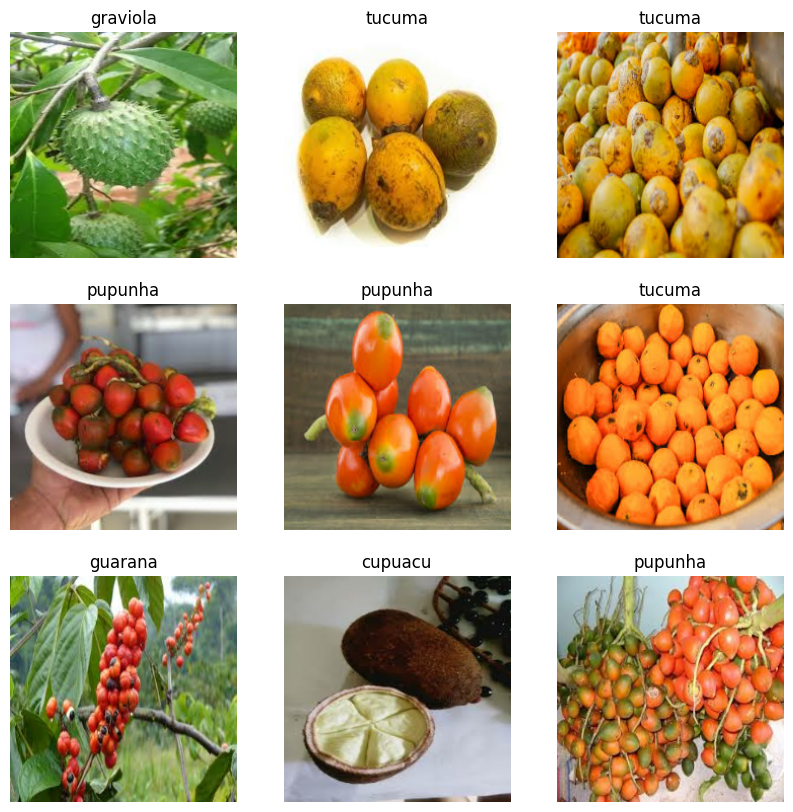

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [28]:
for image_batch, labels_batch in train_dataset:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


## Design CNN Architecture:

For this task, we will build a CNN with following layers:

Feature-Extraction and Convolution Operations.
1.   Convolutional Layer [F=(3,3),K=16,P="same",S=1]-> Activation["ReLU"].
2.   Pooling layer[max, F=(2,2), S=2].
3.   Convolutional Layer [F=(3,3),K=16,P="same",S=1]-> Activation["ReLU"].
4.   Pooling layer[max, F=(2,2), S=2].

Classification-Assigning a class probabilities to each classes.
1.   Flatten Layer()
2.   Hidden/Dense Layer [number of neurons=128].
3.   Output Layer [number of neurons=num_classes].


### Exercise:

Please fill the hyper-parameters as defined above in the below layers.

In [40]:
from tensorflow.keras import layers

def generate_model(image_height, image_width, nchannels, num_classes):
    """
    This function will generate a model with set of hyperparameters defined above.
    """
    model = tf.keras.Sequential([
        # Rescaling and input layer, [For keras the input shape must be(image height, image width, channels)]
        layers.Rescaling(1./255, input_shape=(image_height, image_width, nchannels)),

        # First Block of Convolution and Pooling Operations.
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Second Block of Convolution and Pooling Operations.
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Global Average Pooling Layer (automatically reduces dimensionality)
        layers.GlobalAveragePooling2D(),

        # Fully connected classifier.
        layers.Dense(128, activation="relu"),  # Dense layer with 128 neurons
        layers.Dense(num_classes, activation="softmax")  # Output layer with softmax activation
    ])

    return model


img_height = 180
img_width = 180

In [41]:
num_classes = len(class_names)
model = generate_model(img_height, img_width, 3, num_classes)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 90, 90, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 45, 45, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 16)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,718 (22.34 KB)

 Trainable params: 5,718 (22.34 KB)

 Non-trainable params: 0 (0.00 B)

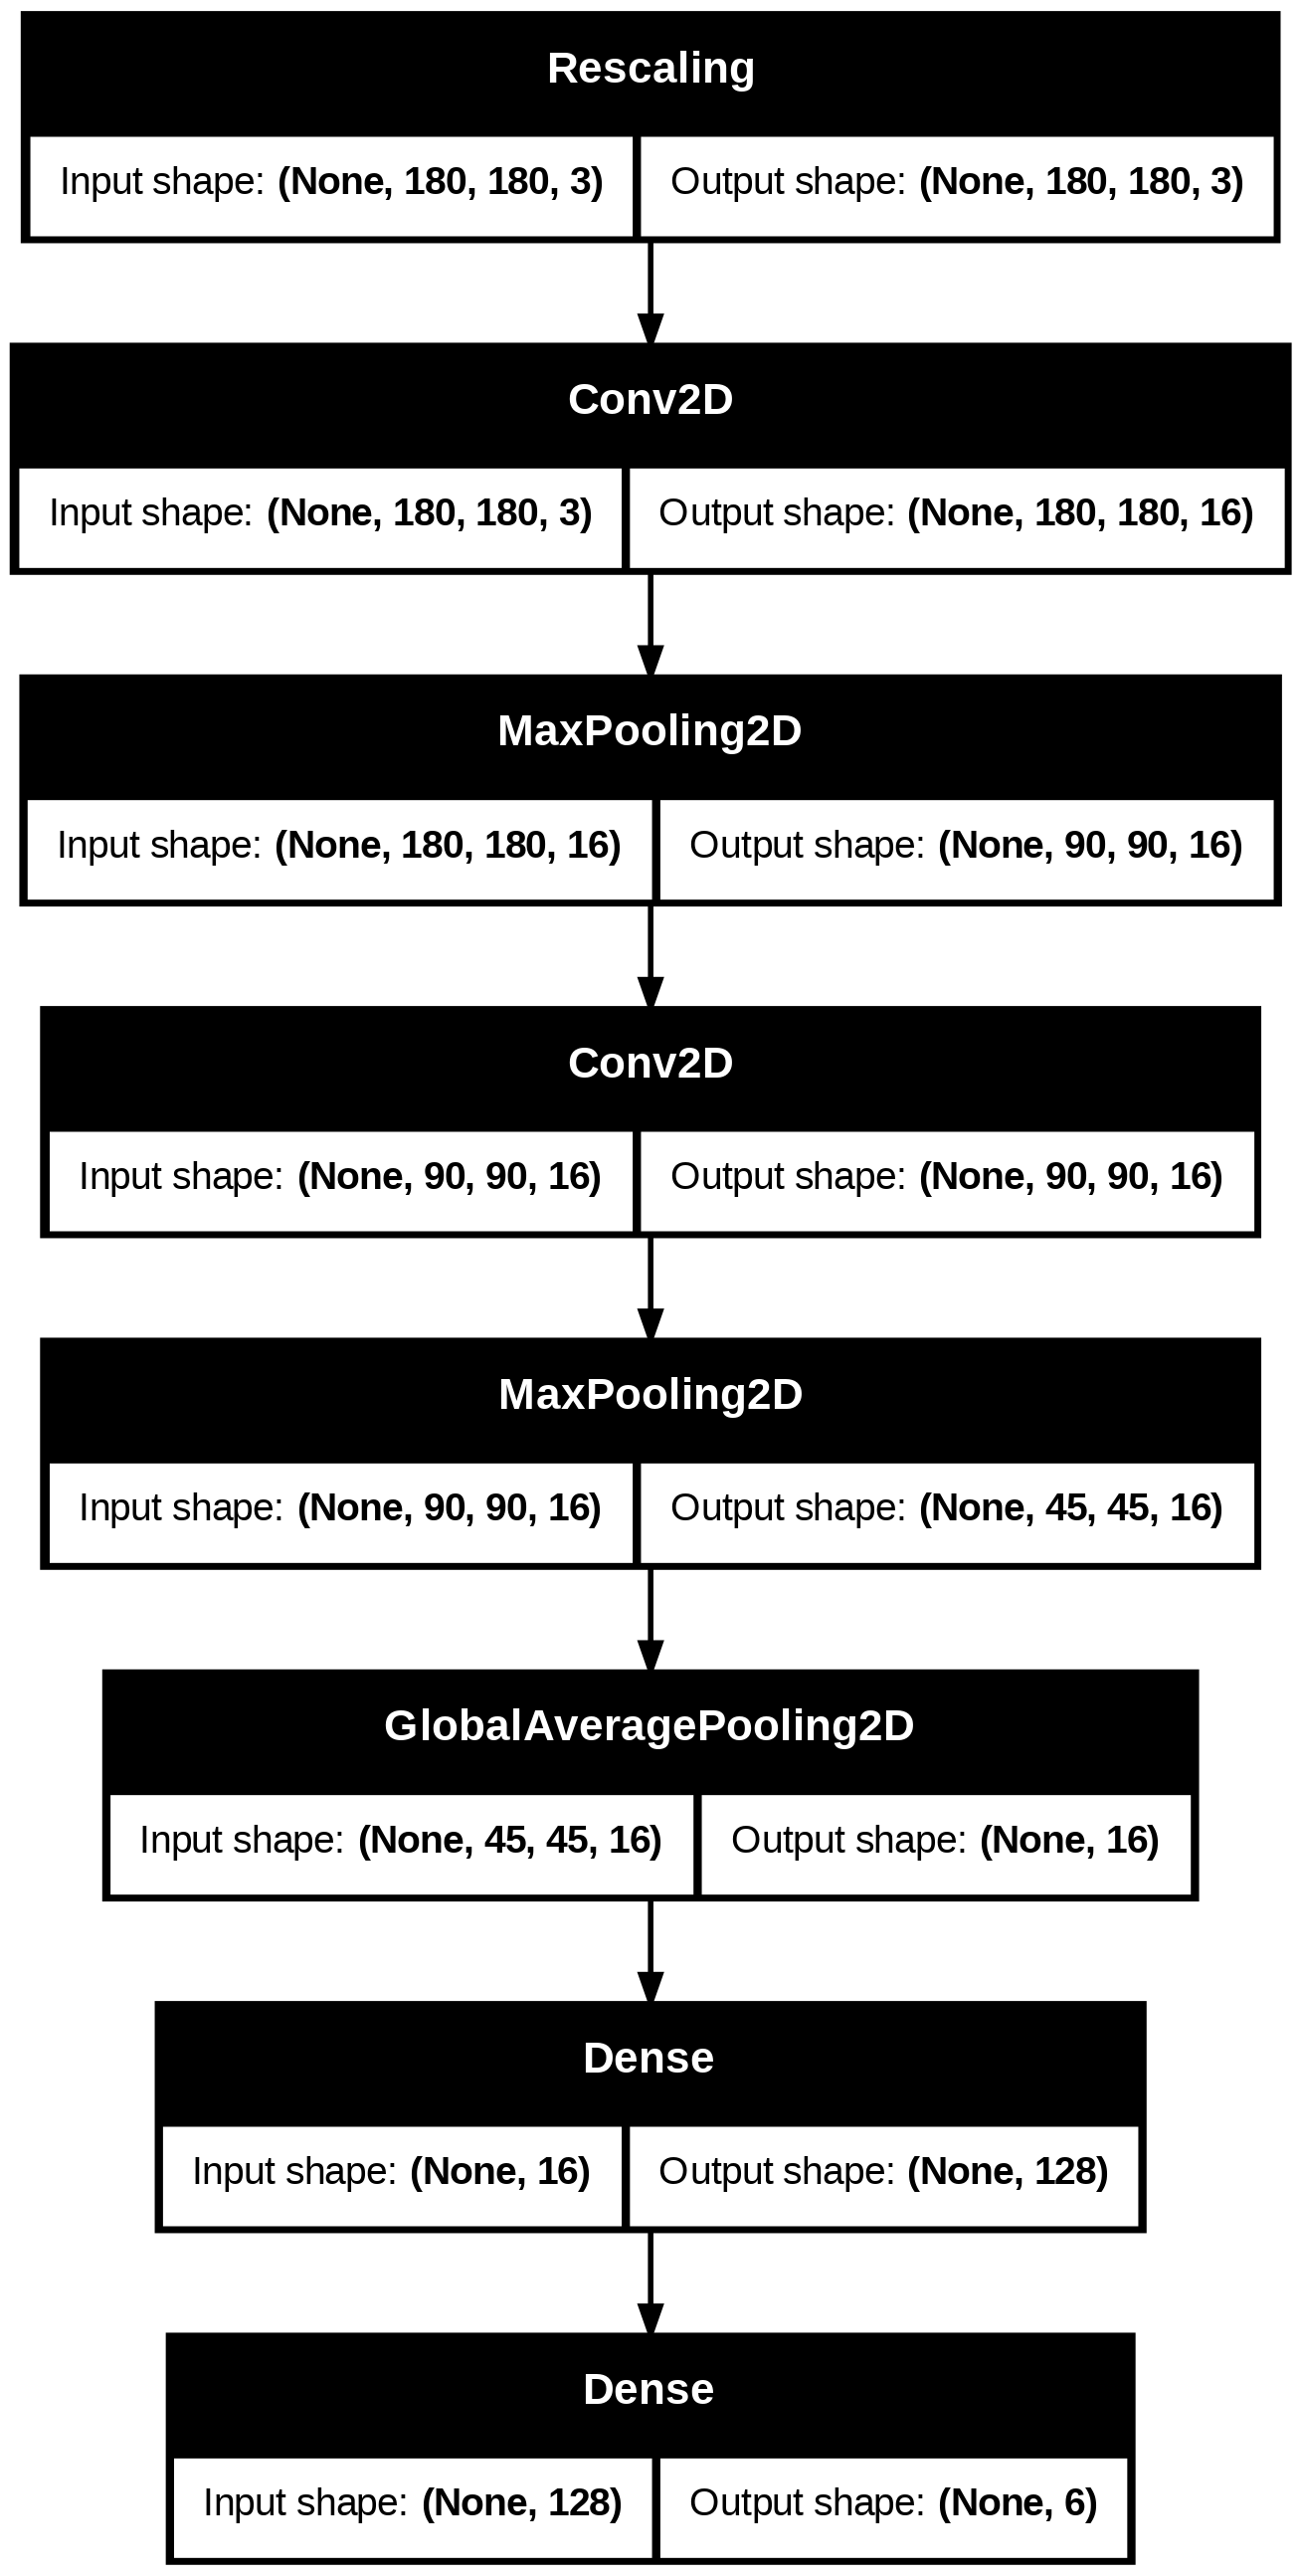

In [43]:
keras.utils.plot_model(model, show_shapes=True)

## Compile and Train Model.

Once we built the model, we need to compile the model before we start training.

In Model compilation, we do the following:
*   Checks for format Error.
*   Defines the loss function.
*   Defines the optimizer.
*   Defines the learning rate.
*   Defines the metrics we will be using.

For training our model we will be using:
*   loss --> SparseCategoricalCrossEntropy.
*   Optimizer --> Adam.
*   Evaluation Metric --> Accuracy.


In [44]:
def compile_and_train_model(model, train_ds, val_ds, epochs=10, learning_rate=0.001):
    """
    This function will compile and train the model.
    Input Args:
    model -> The CNN model to compile and train.
    train_ds -> The training dataset.
    val_ds -> The validation dataset.
    epochs[int] -> Number of epochs to train the model.
    learning_rate[float] -> Learning rate for the optimizer.
    Output Args:
    history -> The training history object.
    """

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),  # Adam optimizer with learning rate
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # Sparse Categorical Crossentropy for multi-class classification
        metrics=['accuracy']  # Metrics to evaluate, using accuracy here
    )

    # Train the model
    history = model.fit(
        train_ds,  # Training data
        validation_data=val_ds,  # Validation data
        epochs=epochs  # Number of training epochs
    )

    return history


### Train the Model.

For training a model with all the given hyper-parameters, and argumets we invoke fit methods.

It is a standard practise to return and hold record of losses values and metric values during training in variablel-history.

In [45]:
# Train the model using the function created
history = compile_and_train_model(model, train_dataset, val_ds, epochs=10, learning_rate=0.001)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1793 - loss: 1.7983 - val_accuracy: 0.0556 - val_loss: 1.7981
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 770ms/step - accuracy: 0.1793 - loss: 1.7887 - val_accuracy: 0.0556 - val_loss: 1.8009
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 752ms/step - accuracy: 0.2105 - loss: 1.7824 - val_accuracy: 0.0556 - val_loss: 1.8034
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 981ms/step - accuracy: 0.2300 - loss: 1.7766 - val_accuracy: 0.0556 - val_loss: 1.8039
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 795ms/step - accuracy: 0.1793 - loss: 1.7820 - val_accuracy: 0.0556 - val_loss: 1.8003
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 789ms/step - accuracy: 0.1949 - loss: 1.7726 - val_accuracy: 0.1111 - val_loss: 1.7984
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 800ms/step - accuracy: 0.2027 - loss: 1.7660 - val_accuracy: 0.1111 - val_loss: 1.7970
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 773ms/step - accuracy: 0.2088 - loss: 1.7657 - val_accuracy: 0.1667 - val_loss: 1.

## Observe the Model Performance.


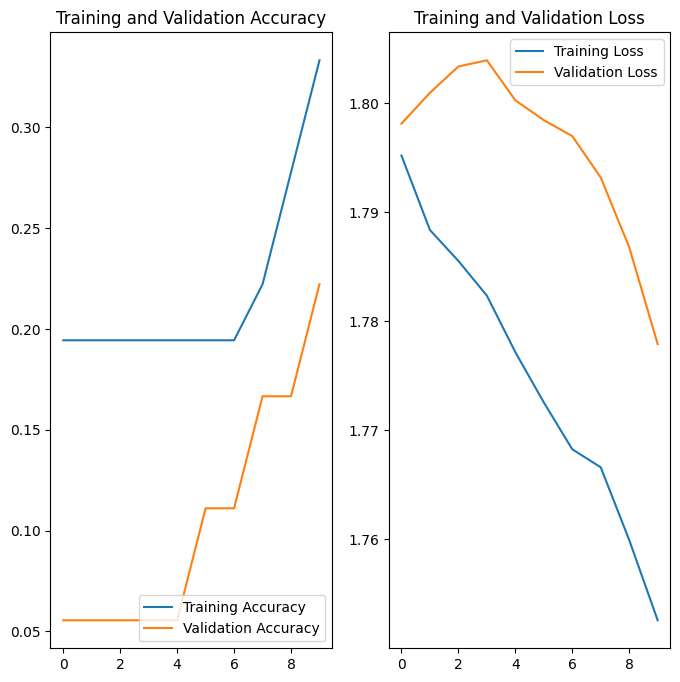

In [46]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Home Task:

Create a Test Set and Perform a model evaluation to find the test accuracy.

Based on last week built a function which predicts input examples, and also plot the result.


1. Import Necessary Libraries

In [51]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


2. Define Your Dataset

In [52]:
# Example dataset
X = np.random.rand(100, 286, 384)  # 100 grayscale images of size 286x384
y = np.random.randint(0, 2, size=100)  # Binary labels (0 or 1)

# Reshape X to include channel dimension
X = X.reshape(-1, 286, 384, 1)  # For grayscale images


3. Split Data into Training, Validation, and Test Sets

In [53]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


4. Define Model Architecture

In [54]:
# Define image dimensions
image_height = 286
image_width = 384
channels = 1  # For grayscale images

num_classes = 2  # Binary classification

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(image_height, image_width, channels)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
